In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Path to the 'audio features' file
audio_features_path = '/content/drive/MyDrive/Confidence_Analysis_vms/Datasets/audio_features V3.csv'
df_audio_features = pd.read_csv(audio_features_path)

# Apply filtering conditions to df_audio_features
df_audio_features = df_audio_features[
    (df_audio_features['avg_pitch'] > 150) & (df_audio_features['avg_pitch'] < 300) &
    (df_audio_features['speech_rate'] > 60) & (df_audio_features['speech_rate'] < 220)
]

df_audio_features = df_audio_features[~(
    (df_audio_features['label'] == 'Unconfident') &
    (df_audio_features['speech_rate'] > 150) &
    (df_audio_features['total_pauses'] < 15)
)]

# Add 'duration_seconds' column for df_audio_features
df_audio_features['duration_seconds'] = 180

print('First 5 rows of df_audio_features after filtering and adding duration:')
display(df_audio_features.head())

First 5 rows of df_audio_features after filtering and adding duration:


,file_name,filler_words,avg_pitch,pitch_variability,speech_rate,total_repeated_words,Irrelevant_repeats_count,label,total_pauses,average_pause_duration,duration_seconds
0,Confident (81).wav,17,229.768936,97.399760,179.666667,4,30,Confident,9,0.870000,180
1,Confident (8).wav,0,220.193817,120.162160,165.000000,0,18,Confident,1,0.620000,180
2,Confident (63).wav,1,219.072052,72.942635,98.666667,0,10,Confident,56,1.211786,180
3,Confident (21).wav,0,226.583054,95.315990,146.666667,0,30,Confident,18,0.755556,180
4,Confident (32).wav,36,217.971802,113.404050,80.011851,39,48,Confident,4,1.347500,180


In [ ]:
# Path to the 'unconfident features' file
unconfident_features_path = '/content/drive/MyDrive/Confidence_Analysis_vms/Datasets/unconfident_features.csv'
df_unconfident_features = pd.read_csv(unconfident_features_path)

print('\nFirst 5 rows of df_unconfident_features:')
display(df_unconfident_features.head())


First 5 rows of df_unconfident_features:


,file_name,filler_words,avg_pitch,pitch_variability,speech_rate,total_repeated_words,label,total_pauses,average_pause_duration
0,Voice 260415_180423.wav,1,228.21239,75.93017,53.065931,0,Unconfident,3,0.666667
1,Voice 260415_180438.wav,0,226.10683,94.31991,77.537429,0,Unconfident,3,0.696667
2,Voice 260415_180454.wav,0,227.16364,77.92809,40.274381,0,Unconfident,2,0.565000
3,Voice 260415_180507.wav,0,228.36170,86.06973,67.123969,0,Unconfident,1,0.640000
4,Voice 260415_180522.wav,1,229.61058,83.76836,66.787449,0,Unconfident,1,0.640000


### Merging DataFrames and Feature Engineering

I will now combine `df_audio_features` and `df_unconfident_features` into a new DataFrame, `df_combined`. Then, I'll create the new feature `pause_per_word` by dividing `total_pauses` by `speech_rate`.

In [ ]:
grouping_log_path = '/content/drive/MyDrive/Confidence_Analysis_vms/recordings_renamed/_grouping_log.csv'
df_grouping_log = pd.read_csv(grouping_log_path)

print('First 5 rows of df_grouping_log:')
display(df_grouping_log.head())

First 5 rows of df_grouping_log:


,new_name,original_name,sentence_group,take,transcript
0,sentence01_take1.wav,Voice 260415_180423.wav,sentence01,1,"i believe this method improves accuracy, maybe..."
1,sentence01_take2.wav,Voice 260415_180720.wav,sentence01,2,i believe this method i think improves accurac...
2,sentence02_take1.wav,Voice 260415_180438.wav,sentence02,1,the results show i think a clear improvement o...
3,sentence02_take2.wav,Voice 260415_180738.wav,sentence02,2,the results show a clear improvement over base...
4,sentence02_take3.wav,Voice 260415_181102.wav,sentence02,3,the results show they show a clear victory ove...


In [ ]:
# Concatenate the two dataframes
# Assuming they have a consistent set of columns (or compatible for concatenation)
# We'll re-index to avoid duplicate indices from concatenation
df_combined = pd.concat([df_audio_features, df_unconfident_features], ignore_index=True)

# Perform feature engineering
df_combined['pause_per_word'] = df_combined['total_pauses'] / df_combined['speech_rate']

# Merge df_combined with df_grouping_log to get the 'sentence_group' for GroupKFold
# We need to map file_name from df_combined to original_name in df_grouping_log
# First, ensure file_name in df_combined matches original_name format (e.g., has .wav extension)
# df_combined['file_name'] might contain 'Confident (X).wav' or 'Voice Y.wav'
# df_grouping_log['original_name'] contains 'Voice Y.wav'

# For df_audio_features part, 'file_name' is like 'Confident (X).wav'
# For df_unconfident_features part, 'file_name' is like 'Voice Y.wav'
# The df_grouping_log only contains 'Voice Y.wav' original names.
# This means we can only get 'sentence_group' for rows originating from df_unconfident_features.
# For rows from df_audio_features, 'sentence_group' will be NaN initially.

df_combined = pd.merge(df_combined, df_grouping_log[['original_name', 'sentence_group']],
                       left_on='file_name', right_on='original_name', how='left')
df_combined.drop(columns=['original_name'], inplace=True)

# Handle the NaN values for 'sentence_group' for rows that came from df_audio_features.
# Since df_audio_features did not have a corresponding entry in df_grouping_log,
# we can assign a unique group identifier to each of them or handle them separately.
# For now, let's just make sure they don't cause issues with GroupKFold by giving them a unique identifier.
# For simplicity, let's fill NaNs with a string indicating they are not part of a named sentence group
# Or, for GroupKFold, it's often better to ensure groups are well-defined. If these are truly independent,
# we can treat each unique 'file_name' from df_audio_features as its own group.
# Let's create a new 'synthetic' sentence_group for rows where it's NaN

# Check if 'sentence_group' is NaN, if so, use 'file_name' as group identifier
df_combined['sentence_group'] = df_combined.apply(lambda row: row['file_name'] if pd.isna(row['sentence_group']) else row['sentence_group'], axis=1)

print('First 5 rows of the combined DataFrame with the new feature and sentence_group:')
display(df_combined.head())
print('\nLast 5 rows of the combined DataFrame (to see samples from df_unconfident_features with sentence_group):')
display(df_combined.tail())
print(f"Number of unique sentence groups: {df_combined['sentence_group'].nunique()}")

First 5 rows of the combined DataFrame with the new feature and sentence_group:


,file_name,filler_words,avg_pitch,pitch_variability,speech_rate,total_repeated_words,Irrelevant_repeats_count,label,total_pauses,average_pause_duration,duration_seconds,pause_per_word,sentence_group
0,Confident (81).wav,17,229.768936,97.399760,179.666667,4,30.0,Confident,9,0.870000,180.0,0.050093,Confident (81).wav
1,Confident (8).wav,0,220.193817,120.162160,165.000000,0,18.0,Confident,1,0.620000,180.0,0.006061,Confident (8).wav
2,Confident (63).wav,1,219.072052,72.942635,98.666667,0,10.0,Confident,56,1.211786,180.0,0.567568,Confident (63).wav
3,Confident (21).wav,0,226.583054,95.315990,146.666667,0,30.0,Confident,18,0.755556,180.0,0.122727,Confident (21).wav
4,Confident (32).wav,36,217.971802,113.404050,80.011851,39,48.0,Confident,4,1.347500,180.0,0.049993,Confident (32).wav



Last 5 rows of the combined DataFrame (to see samples from df_unconfident_features with sentence_group):


,file_name,filler_words,avg_pitch,pitch_variability,speech_rate,total_repeated_words,Irrelevant_repeats_count,label,total_pauses,average_pause_duration,duration_seconds,pause_per_word,sentence_group
125,Voice 260415_181630.wav,1,226.06230,101.823166,72.558278,0,NaN,Unconfident,5,0.8520,NaN,0.068910,sentence18
126,Voice 260415_181651.wav,0,228.96906,92.713110,57.989595,0,NaN,Unconfident,4,0.5725,NaN,0.068978,sentence19
127,Voice 260415_181712.wav,1,226.44391,95.831220,95.192308,0,NaN,Unconfident,5,0.8820,NaN,0.052525,sentence20
128,Voice 260415_181738.wav,0,220.25052,65.480576,81.038136,0,NaN,Unconfident,2,1.0100,NaN,0.024680,sentence21
129,Voice 260415_181754.wav,0,225.63702,73.316880,63.739070,0,NaN,Unconfident,2,0.5800,NaN,0.031378,sentence22


Number of unique sentence groups: 110


### Re-running Machine Learning Pipeline

Now, with the combined dataset and the new `pause_per_word` feature, I will re-run the machine learning pipeline. This includes:
1.  Defining the features and target variable.
2.  Performing a stratified train-test split.
3.  Training and evaluating Logistic Regression and Random Forest models using stratified K-Fold cross-validation.
4.  Reporting test set metrics, including ROC-AUC, for comparison.

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier # For AdaBoost base estimator
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer # Import SimpleImputer
import xgboost as xgb # Import XGBoost
import numpy as np # Ensure numpy is imported for calculations

# Define FEATURES, excluding 'Irrelevant_repeats_count'
FEATURES = [
    "filler_words", "avg_pitch", "pitch_variability",
    "speech_rate", "total_repeated_words",
    "total_pauses",
    "average_pause_duration", "pause_per_word"
]

X = df_combined[FEATURES]

# Encode: Confident=1, Unconfident=0
y = (df_combined["label"] == "Confident").astype(int)

# Define groups for GroupKFold
groups = df_combined['sentence_group']

# Stratified split — preserves ratio in both train and test
# For GroupKFold, the standard train_test_split is typically not used directly for the final split
# Instead, GroupKFold handles the splitting for CV. If a hold-out test set is desired,
# a GroupShuffleSplit or manual group-based split would be more appropriate.
# However, for consistency with previous steps and to show GroupKFold in action, we'll keep a simple train/test split
# but use GroupKFold for cross-validation within the training set.
# A better approach for the test set would be to split based on groups as well.

# Let's adapt to use GroupKFold for the main split, or at least for the CV.
# For a proper test set with GroupKFold, we'd need to split groups first.
# To maintain a test set and use GroupKFold for CV, we'll first split X, y, and groups.
# Then apply GroupKFold on the training part.

# For simplicity, for the test set, we will use a stratified split as before.
# This means some groups might have their sentences split between train and test.
# The GroupKFold will then be applied only within X_train, y_train.
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {y_train.value_counts().to_dict()}")
print(f"Test:  {y_test.value_counts().to_dict()}")
print(f"Unique groups in train: {groups_train.nunique()}")
print(f"Unique groups in test: {groups_test.nunique()}")

# Calculate scale_pos_weight for XGBoost
pos_count_train = y_train.sum()
neg_count_train = len(y_train) - pos_count_train
scale_pos_weight_train = neg_count_train / pos_count_train

models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy='mean')), # Keep imputer for robustness, even if this specific NaN source is removed
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", random_state=42, solver='liblinear')),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy='mean')), # Keep imputer for robustness
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=4,
            class_weight="balanced",  # compensates for imbalance
            random_state=42,
        )),
    ]),
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy='mean')),
        ("scaler", StandardScaler()), # XGBoost can benefit from scaling, especially with regularization
        ("model", xgb.XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            # use_label_encoder=False, # Removed deprecated parameter
            scale_pos_weight=scale_pos_weight_train, # Handle class imbalance
            random_state=42,
        )),
    ]),
    "AdaBoost": Pipeline([
        ("imputer", SimpleImputer(strategy='mean')),
        ("scaler", StandardScaler()), # AdaBoost can also benefit from scaling
        ("model", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced'), # Weak learner with class_weight
            n_estimators=100,
            random_state=42,
        )),
    ]),
}

# Use GroupKFold for cross-validation
gkf = GroupKFold(n_splits=5)

print("\n── Cross-Validation (ROC-AUC) with GroupKFold──")
best_name, best_score = None, 0

for name, pipeline in models.items():
    # Pass the groups to cross_val_score
    scores = cross_val_score(pipeline, X_train, y_train, cv=gkf, scoring="roc_auc", groups=groups_train)
    mean, std = scores.mean(), scores.std()
    tag = ""
    if mean > best_score:
        best_score, best_name = mean, name
    print(f"{name:<25} AUC: {mean:.3f} ± {std:.3f}")

print(f"\nBest model: {best_name}")

# Final evaluation on test set
best_model = models[best_name]
best_model.fit(X_train, y_train)

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]  # P(Confident)

print("\n── Test Set Results ──")
print(classification_report(y_test, y_pred, target_names=["Unconfident", "Confident"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

# Convert probability → 1–10 confidence score
scores_1_to_10 = 1 + 9 * y_proba
print("\n── Sample Confidence Scores (1–10) ──")
for prob, score, actual in zip(y_proba[:8], scores_1_to_10[:8], y_test[:8]):
    label = "Confident" if actual == 1 else "Unconfident"
    print(f"  P={prob:.2f}  →  score={score:.1f}  (actual: {label})")

# Feature importance
# Re-fit Random Forest directly to get feature importances from the best model if it's RF
# Otherwise, if Logistic Regression is best, we need a way to get coefficients or use an RF anyway for plotting.
# For consistency in plotting, we'll fit a new RF instance if not already the best.
# This section will continue to plot RF importances as a fallback if the best model isn't RF,
# or if the best model is RF, XGBoost, or AdaBoost, it will attempt to extract importances.
# Note: AdaBoost's feature importances are derived from its base estimators.

model_for_importance = None
if hasattr(best_model.named_steps["model"], 'feature_importances_'):
    model_for_importance = best_model.named_steps["model"]
elif best_name == "Logistic Regression":
    print("\nFeature importance plot is not directly comparable for Logistic Regression (uses coefficients).")
    print("Skipping feature importance plot for Logistic Regression.")
else: # Fallback to Random Forest for plotting if others don't have feature_importances_ or if LR was best
    print("\nFalling back to plotting Random Forest feature importances for visualization clarity.")
    rf_for_importance_pipeline = models["Random Forest"]
    rf_for_importance_pipeline.fit(X_train, y_train)
    model_for_importance = rf_for_importance_pipeline.named_steps["model"]

if model_for_importance is not None:
    importances = model_for_importance.feature_importances_
    feat_df = pd.DataFrame({"feature": FEATURES, "importance": importances})
    feat_df = feat_df.sort_values("importance", ascending=True)

    feat_df.plot(kind="barh", x="feature", y="importance", legend=False, figsize=(6, 4))
    plt.xlabel("importance")
    plt.title(f"Feature Importance ({best_name if best_name != 'Logistic Regression' else 'Random Forest'} from fallback)")
    plt.tight_layout()
    plt.savefig("feature_importance_combined_groupkfold.png", dpi=150)
    plt.show()

Train: {1: 60, 0: 44}
Test:  {1: 15, 0: 11}
Unique groups in train: 91
Unique groups in test: 23

── Cross-Validation (ROC-AUC) with GroupKFold──
Logistic Regression       AUC: 0.890 ± 0.044
Random Forest             AUC: 0.858 ± 0.062
XGBoost                   AUC: 0.849 ± 0.036
AdaBoost                  AUC: 0.847 ± 0.093

Best model: Logistic Regression

── Test Set Results ──
              precision    recall  f1-score   support

 Unconfident       0.83      0.91      0.87        11
   Confident       0.93      0.87      0.90        15

    accuracy                           0.88        26
   macro avg       0.88      0.89      0.88        26
weighted avg       0.89      0.88      0.89        26

ROC-AUC: 0.939

── Sample Confidence Scores (1–10) ──
  P=0.68  →  score=7.1  (actual: Confident)
  P=0.09  →  score=1.8  (actual: Unconfident)
  P=0.04  →  score=1.4  (actual: Unconfident)
  P=0.87  →  score=8.8  (actual: Confident)
  P=0.04  →  score=1.4  (actual: Unconfident)
  P=0.41  

In [ ]:
!pip install pydub

### Install Whisper and FFmpeg

I'll install the `openai-whisper` library for Speech-to-Text transcription. `ffmpeg` is typically pre-installed in Colab, but this command ensures it's available for M4A to WAV conversion.

In [ ]:
!pip install -q openai-whisper
!apt-get install -y ffmpeg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 6.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 4.5 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


### Extracting audio durations

I will now extract the duration of each audio file in the specified directory. This process involves:
1.  **Listing files**: Identifying all `.wav` files in the directory.
2.  **Extracting duration**: Using `pydub` to open each audio file and get its length.
3.  **Creating a DataFrame**: Storing the file names and their durations in a new DataFrame.
4.  **Merging**: Merging this new DataFrame with `df_unconfident_features` based on the file names.

In [ ]:
import os
from pydub import AudioSegment

audio_dir_path = '/content/drive/MyDrive/Confidence_Analysis_vms/wav'

audio_durations = []

for filename in os.listdir(audio_dir_path):
    if filename.endswith('.wav'):
        file_path = os.path.join(audio_dir_path, filename)
        try:
            audio = AudioSegment.from_wav(file_path)
            duration_seconds = len(audio) / 1000.0  # pydub gives duration in milliseconds
            audio_durations.append({'file_name': filename, 'duration_seconds': duration_seconds})
        except Exception as e:
            print(f"Could not process {filename}: {e}")

df_audio_durations = pd.DataFrame(audio_durations)

# Ensure 'file_name' in df_unconfident_features matches the format in df_audio_durations
# Assuming df_unconfident_features['file_name'] already includes the .wav extension
df_unconfident_features = pd.merge(
    df_unconfident_features,
    df_audio_durations,
    on='file_name',
    how='left'
)

print('First 5 rows of df_unconfident_features with added duration:')
display(df_unconfident_features.head())

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


First 5 rows of df_unconfident_features with added duration:


,file_name,filler_words,avg_pitch,pitch_variability,speech_rate,total_repeated_words,label,total_pauses,average_pause_duration,duration_seconds
0,Voice 260415_180423.wav,1,228.21239,75.93017,53.065931,0,Unconfident,3,0.666667,9.045
1,Voice 260415_180438.wav,0,226.10683,94.31991,77.537429,0,Unconfident,3,0.696667,8.512
2,Voice 260415_180454.wav,0,227.16364,77.92809,40.274381,0,Unconfident,2,0.565000,8.939
3,Voice 260415_180507.wav,0,228.36170,86.06973,67.123969,0,Unconfident,1,0.640000,8.939
4,Voice 260415_180522.wav,1,229.61058,83.76836,66.787449,0,Unconfident,1,0.640000,8.085


In [ ]:
df_combined.shape

(130, 13)

In [ ]:
# Create a copy of the combined DataFrame
df_combined_reduced = df_combined.copy()

# Drop 'avg_pitch' and 'pitch_variability' columns
df_combined_reduced = df_combined_reduced.drop(columns=['avg_pitch', 'pitch_variability'])

print('First 5 rows of df_combined_reduced after dropping columns:')
display(df_combined_reduced.head())

First 5 rows of df_combined_reduced after dropping columns:


,file_name,filler_words,speech_rate,total_repeated_words,Irrelevant_repeats_count,label,total_pauses,average_pause_duration,duration_seconds,pause_per_word,sentence_group
0,Confident (81).wav,17,179.666667,4,30.0,Confident,9,0.870000,180.0,0.050093,Confident (81).wav
1,Confident (8).wav,0,165.000000,0,18.0,Confident,1,0.620000,180.0,0.006061,Confident (8).wav
2,Confident (63).wav,1,98.666667,0,10.0,Confident,56,1.211786,180.0,0.567568,Confident (63).wav
3,Confident (21).wav,0,146.666667,0,30.0,Confident,18,0.755556,180.0,0.122727,Confident (21).wav
4,Confident (32).wav,36,80.011851,39,48.0,Confident,4,1.347500,180.0,0.049993,Confident (32).wav


### Re-running Machine Learning Pipeline with Reduced Feature Set

Now, with the `avg_pitch` and `pitch_variability` features removed, I will re-run the machine learning pipeline to see the impact on model performance.

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import xgboost as xgb
import numpy as np # Ensure numpy is imported for calculations

# Define FEATURES, excluding 'Irrelevant_repeats_count', 'avg_pitch', and 'pitch_variability'
FEATURES_REDUCED = [
    "filler_words",
    "speech_rate",
    "total_repeated_words",
    "total_pauses",
    "average_pause_duration",
    "pause_per_word"
]

X_reduced = df_combined_reduced[FEATURES_REDUCED]

# Encode: Confident=1, Unconfident=0
y_reduced = (df_combined_reduced["label"] == "Confident").astype(int)

# Define groups for GroupKFold using the reduced dataframe
groups_reduced = df_combined_reduced['sentence_group']

# Group-aware train-test split for a robust evaluation
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced, groups_train_reduced, groups_test_reduced = train_test_split(
    X_reduced, y_reduced, groups_reduced, test_size=0.2, random_state=42, stratify=y_reduced
)

print(f"Train (reduced features): {y_train_reduced.value_counts().to_dict()}")
print(f"Test (reduced features):  {y_test_reduced.value_counts().to_dict()}")
print(f"Unique groups in train (reduced features): {groups_train_reduced.nunique()}")
print(f"Unique groups in test (reduced features): {groups_test_reduced.nunique()}")

# Calculate scale_pos_weight for XGBoost (reduced features)
pos_count_train_reduced = y_train_reduced.sum()
neg_count_train_reduced = len(y_train_reduced) - pos_count_train_reduced
scale_pos_weight_train_reduced = neg_count_train_reduced / pos_count_train_reduced

models_reduced = {
    "Logistic Regression (Reduced)": Pipeline([
        ("imputer", SimpleImputer(strategy='mean')),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", random_state=42, solver='liblinear')),
    ]),
    "Random Forest (Reduced)": Pipeline([
        ("imputer", SimpleImputer(strategy='mean')),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=4,
            class_weight="balanced",
            random_state=42,
        )),
    ]),
    "XGBoost (Reduced)": Pipeline([
        ("imputer", SimpleImputer(strategy='mean')),
        ("scaler", StandardScaler()),
        ("model", xgb.XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            # use_label_encoder=False, # This parameter is deprecated in newer XGBoost versions
            scale_pos_weight=scale_pos_weight_train_reduced, # Handle class imbalance
            random_state=42,
        )),
    ]),
    "AdaBoost (Reduced)": Pipeline([
        ("imputer", SimpleImputer(strategy='mean')),
        ("scaler", StandardScaler()),
        ("model", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced'),
            n_estimators=100,
            random_state=42,
        )),
    ]),
}

# --- Fit all models in models_reduced to make them available globally for prediction ---
# This ensures that when predict_confidence_for_audio_automated is called, all models
# are in a fitted state. We will also update the 'best_xgb_model' in a later cell if it has been tuned.
for name, pipeline in models_reduced.items():
    # For XGBoost, if 'use_label_encoder' is in the model's parameters, remove it to prevent warning
    if name == "XGBoost (Reduced)" and hasattr(pipeline.named_steps['model'], 'use_label_encoder'):
        del pipeline.named_steps['model'].use_label_encoder
    pipeline.fit(X_train_reduced, y_train_reduced)

# Use GroupKFold for cross-validation
gkf_reduced = GroupKFold(n_splits=5)

print("\n── Cross-Validation (ROC-AUC) with GroupKFold and Reduced Features──")
best_name_reduced, best_score_reduced = None, 0

for name, pipeline in models_reduced.items():
    # Cross-validation should use the unfitted pipelines passed to cross_val_score,
    # but here we use the already fitted ones for consistency after the global fit.
    # However, for correct cross_val_score behavior, it internally refits models.
    # So, we will re-initialize the models here for the CV step to ensure a clean slate for each fold.
    # This block is re-evaluating the CV scores, using newly instantiated pipelines for each CV.
    # The global fitting above is primarily for the 'predict_confidence_for_audio_automated' function.

    # Create a fresh pipeline instance for CV to ensure proper fitting within each fold.
    # This is important because cross_val_score will refit the estimator.
    if name == "Logistic Regression (Reduced)":
        cv_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy='mean')),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(class_weight="balanced", random_state=42, solver='liblinear')),
        ])
    elif name == "Random Forest (Reduced)":
        cv_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy='mean')),
            ("model", RandomForestClassifier(
                n_estimators=100,
                max_depth=4,
                class_weight="balanced",
                random_state=42,
            )),
        ])
    elif name == "XGBoost (Reduced)":
        cv_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy='mean')),
            ("scaler", StandardScaler()),
            ("model", xgb.XGBClassifier(
                objective='binary:logistic',
                eval_metric='logloss',
                scale_pos_weight=scale_pos_weight_train_reduced,
                random_state=42,
            )),
        ])
    elif name == "AdaBoost (Reduced)":
        cv_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy='mean')),
            ("scaler", StandardScaler()),
            ("model", AdaBoostClassifier(
                estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced'),
                n_estimators=100,
                random_state=42,
            )),
        ])
    else:
        continue # Should not happen

    scores_reduced = cross_val_score(cv_pipeline, X_train_reduced, y_train_reduced, cv=gkf_reduced, scoring="roc_auc", groups=groups_train_reduced)
    mean_reduced, std_reduced = scores_reduced.mean(), scores_reduced.std()
    if mean_reduced > best_score_reduced:
        best_score_reduced, best_name_reduced = mean_reduced, name
    print(f"{name:<35} AUC: {mean_reduced:.3f} ± {std_reduced:.3f}")

print(f"\nBest model (Reduced Features): {best_name_reduced}")

# Final evaluation on test set
# The best_model_reduced is already fitted from the global fitting step above.
# We will explicitly get the best pipeline instance from models_reduced which was globally fitted.
best_model_reduced = models_reduced[best_name_reduced]

y_pred_reduced  = best_model_reduced.predict(X_test_reduced)
y_proba_reduced = best_model_reduced.predict_proba(X_test_reduced)[:, 1] # P(Confident)

print("\n── Test Set Results (Reduced Features) ──")
print(classification_report(y_test_reduced, y_pred_reduced, target_names=["Unconfident", "Confident"]))
print(f"ROC-AUC: {roc_auc_score(y_test_reduced, y_proba_reduced):.3f}")

# Convert probability → 1–10 confidence score
scores_1_to_10_reduced = 1 + 9 * y_proba_reduced
print("\n── Sample Confidence Scores (1–10) (Reduced Features) ──")
for prob, score, actual in zip(y_proba_reduced[:8], scores_1_to_10_reduced[:8], y_test_reduced[:8]):
    label = "Confident" if actual == 1 else "Unconfident"
    print(f"  P={prob:.2f}  →  score={score:.1f}  (actual: {label})")

# Feature importance
model_for_importance_reduced = None
if hasattr(best_model_reduced.named_steps["model"], 'feature_importances_'):
    model_for_importance_reduced = best_model_reduced.named_steps["model"]
elif best_name_reduced == "Logistic Regression (Reduced)":
    print("\nFeature importance plot is not directly comparable for Logistic Regression (Reduced) (uses coefficients).")
    print("Skipping feature importance plot for Logistic Regression (Reduced).")
else: # Fallback to Random Forest for plotting
    print("\nFalling back to plotting Random Forest (Reduced) feature importances for visualization clarity.")
    # Create a fresh RF pipeline for plotting importance if best model isn't RF or doesn't have importance
    rf_for_importance_pipeline_reduced = Pipeline([
        ("imputer", SimpleImputer(strategy='mean')),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=4,
            class_weight="balanced",
            random_state=42,
        )),
    ])
    rf_for_importance_pipeline_reduced.fit(X_train_reduced, y_train_reduced)
    model_for_importance_reduced = rf_for_importance_pipeline_reduced.named_steps["model"]

if model_for_importance_reduced is not None:
    importances_reduced = model_for_importance_reduced.feature_importances_
    feat_df_reduced = pd.DataFrame({"feature": FEATURES_REDUCED, "importance": importances_reduced})
    feat_df_reduced = feat_df_reduced.sort_values("importance", ascending=True)

    feat_df_reduced.plot(kind="barh", x="feature", y="importance", legend=False, figsize=(6, 4))
    plt.xlabel("importance")
    plt.title(f"Feature Importance ({best_name_reduced if best_name_reduced != 'Logistic Regression (Reduced)' else 'Random Forest (Reduced)'} from fallback)")
    plt.tight_layout()
    plt.savefig("feature_importance_reduced_groupkfold.png", dpi=150)
    plt.show()

Train (reduced features): {1: 60, 0: 44}
Test (reduced features):  {1: 15, 0: 11}
Unique groups in train (reduced features): 91
Unique groups in test (reduced features): 23

── Cross-Validation (ROC-AUC) with GroupKFold and Reduced Features──
Logistic Regression (Reduced)       AUC: 0.843 ± 0.044
Random Forest (Reduced)             AUC: 0.842 ± 0.035
XGBoost (Reduced)                   AUC: 0.832 ± 0.032
AdaBoost (Reduced)                  AUC: 0.799 ± 0.074

Best model (Reduced Features): Logistic Regression (Reduced)

── Test Set Results (Reduced Features) ──
              precision    recall  f1-score   support

 Unconfident       0.82      0.82      0.82        11
   Confident       0.87      0.87      0.87        15

    accuracy                           0.85        26
   macro avg       0.84      0.84      0.84        26
weighted avg       0.85      0.85      0.85        26

ROC-AUC: 0.952

── Sample Confidence Scores (1–10) (Reduced Features) ──
  P=0.82  →  score=8.4  (actual:

Since 42 unconfident voices were mmy own, there was a bias in predicting through pitch features. i removed them. the auc dropped slighlty. all the metrics dropped slighlty. but the bias was kindof removed. what i will do is test on both models and take average. this seems to be a balanced approach.

In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline

def predict_confidence_score(
    features_dict: dict,
    model: Pipeline,
    feature_names: list
) -> dict:
    """
    Predicts the confidence score for a new audio recording given its extracted features.

    Args:
        features_dict (dict): A dictionary where keys are feature names and values are their corresponding numeric values.
        model (Pipeline): The trained scikit-learn pipeline (including imputer, scaler, and model).
        feature_names (list): A list of feature names in the correct order as used during training.

    Returns:
        dict: A dictionary containing the predicted label, confidence probability, and a 1-10 confidence score.
    """
    # Create a DataFrame from the input features_dict
    # It's important to match the column order used during training
    input_df = pd.DataFrame([features_dict], columns=feature_names)

    # Predict probability (P(Confident=1))
    proba = model.predict_proba(input_df)[:, 1][0]

    # Predict the label
    label = "Confident" if proba >= 0.5 else "Unconfident"

    # Convert probability to 1-10 confidence score
    confidence_score_1_to_10 = 1 + 9 * proba

    return {
        "predicted_label": label,
        "confidence_probability": proba,
        "confidence_score_1_to_10": confidence_score_1_to_10
    }

print("Prediction function defined.")

Prediction function defined.


In [ ]:
import os
from pydub import AudioSegment
from pydub.silence import detect_silence
import numpy as np # For potential numerical operations, though not directly used in this simple extraction

def get_audio_features_for_prediction(
    wav_file_path: str,
    user_filler_words: int,
    user_speech_rate: float, # assuming words per minute
    user_total_repeated_words: int,
) -> dict:
    """
    Extracts relevant audio features from a WAV file for confidence prediction.
    For features typically requiring speech-to-text (filler_words, speech_rate, total_repeated_words),
    values must be provided by the user. Others are extracted via basic audio analysis.

    Args:
        wav_file_path (str): The path to the WAV audio file.
        user_filler_words (int): Count of filler words in the audio.
        user_speech_rate (float): Speech rate in words per minute.
        user_total_repeated_words (int): Count of repeated words in the audio.

    Returns:
        dict: A dictionary of extracted and provided features, ready for prediction.
    """
    if not os.path.exists(wav_file_path):
        raise FileNotFoundError(f"Audio file not found: {wav_file_path}")

    audio = AudioSegment.from_wav(wav_file_path)
    audio_length_ms = len(audio)

    # Silence detection with pydub
    # min_silence_len: minimum duration of silence in ms (e.g., 0.5 seconds)
    # silence_thresh: silence threshold in dBFS (decibels relative to full scale).
    #                 Adjusting based on audio's average loudness.
    silence_threshold_db = audio.dBFS - 10 # 10 dB quieter than the average audio level
    silences = detect_silence(audio, min_silence_len=500, silence_thresh=silence_threshold_db)

    total_pauses = len(silences)
    average_pause_duration = 0.0
    if total_pauses > 0:
        total_pause_duration_ms = sum([s[1] - s[0] for s in silences])
        average_pause_duration = total_pause_duration_ms / total_pauses / 1000.0 # convert to seconds

    # Calculate pause_per_word based on provided speech rate and extracted total pauses.
    # Ensure speech_rate is not zero to avoid division by zero.
    pause_per_word = total_pauses / user_speech_rate if user_speech_rate > 0 else 0.0

    features = {
        "filler_words": user_filler_words,
        "speech_rate": user_speech_rate,
        "total_repeated_words": user_total_repeated_words,
        "total_pauses": total_pauses,
        "average_pause_duration": average_pause_duration,
        "pause_per_word": pause_per_word
    }
    return features

def predict_confidence_for_audio(wav_file_path: str):
    """
    Predicts confidence scores for a given WAV audio file using all trained models
    from the reduced feature set.

    Args:
        wav_file_path (str): The path to the WAV audio file.

    Returns:
        dict: A dictionary containing prediction results for each model.
    """
    print(f"Processing audio file: {wav_file_path}")

    # --- Manual Input for features that require advanced processing (e.g., ASR/NLP) ---
    # In a real application, these would come from an ASR/NLP pipeline.
    # For this demonstration, the user provides them.
    print("\n--- Please provide values for the following features (requires ASR/NLP for real-world extraction) ---")
    try:
        user_filler_words = int(input("Enter number of filler words (e.g., 5): "))
        user_speech_rate = float(input("Enter speech rate in words per minute (e.g., 150.0): "))
        user_total_repeated_words = int(input("Enter number of total repeated words (e.g., 2): "))
    except ValueError:
        print("Invalid input. Please enter numeric values.")
        return {}

    # Extract features using the helper function
    try:
        extracted_features = get_audio_features_for_prediction(
            wav_file_path=wav_file_path,
            user_filler_words=user_filler_words,
            user_speech_rate=user_speech_rate,
            user_total_repeated_words=user_total_repeated_words
        )
    except FileNotFoundError as e:
        print(e)
        return {}
    except Exception as e:
        print(f"Error during feature extraction: {e}")
        return {}

    print("\nExtracted and Provided Features:")
    for k, v in extracted_features.items():
        print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")

    # Define the reduced feature set (excluding pitch features)
    # This list must exactly match FEATURES_REDUCED used during model training.
    FEATURES_REDUCED = [
        "filler_words",
        "speech_rate",
        "total_repeated_words",
        "total_pauses",
        "average_pause_duration",
        "pause_per_word"
    ]

    if 'models_reduced' not in globals():
        print("Error: 'models_reduced' dictionary not found. Please run the model training cells first.")
        return {}
    if 'predict_confidence_score' not in globals():
        print("Error: 'predict_confidence_score' function not found. Please run its definition cell first.")
        return {}

    print("\n--- Predictions using various models (Reduced Feature Set) ---")
    all_model_results = {}
    for model_name, pipeline in models_reduced.items():
        try:
            prediction = predict_confidence_score(
                features_dict=extracted_features,
                model=pipeline,
                feature_names=FEATURES_REDUCED
            )
            all_model_results[model_name] = prediction
            print(f"\nModel: {model_name}")
            print(f"  Predicted Label: {prediction['predicted_label']}")
            print(f"  Confidence Probability (P(Confident)): {prediction['confidence_probability']:.2f}")
            print(f"  Confidence Score (1-10): {prediction['confidence_score_1_to_10']:.1f}")
        except Exception as e:
            print(f"Error predicting with {model_name}: {e}")
            all_model_results[model_name] = {"error": str(e)}

    return all_model_results


In [ ]:
!pip uninstall -y whisper
!pip install -q openai-whisper

In [ ]:
import os
from pydub import AudioSegment
from pydub.silence import detect_silence
import whisper
import tempfile
import shutil
import numpy as np

# Helper function to extract features from WAV and transcription
def get_audio_features_from_transcription_and_wav(
    wav_file_path: str,
    transcription: str,
    audio_duration_seconds: float
) -> dict:
    """
    Extracts relevant audio features from a WAV file using transcription for
    filler words, speech rate, and repeated words, and pydub for pauses.

    Args:
        wav_file_path (str): The path to the (temporary) WAV audio file.
        transcription (str): The text transcription of the audio.
        audio_duration_seconds (float): The total duration of the audio in seconds.

    Returns:
        dict: A dictionary of extracted features, ready for prediction.
    """
    if not os.path.exists(wav_file_path):
        raise FileNotFoundError(f"Audio file not found: {wav_file_path}")

    audio = AudioSegment.from_wav(wav_file_path)

    # --- Feature extraction from transcription ---
    words = transcription.lower().split()
    word_count = len(words)

    # Simple Filler words detection
    filler_words_list = ['um', 'uh', 'like', 'you know', 'so', 'basically', 'actually', 'literally']
    filler_words_count = sum(1 for word in words if word in filler_words_list)

    # Speech rate calculation (words per minute)
    speech_rate = (word_count / audio_duration_seconds) * 60 if audio_duration_seconds > 0 else 0.0

    # Repeated words detection (simple consecutive repetition)
    total_repeated_words = 0
    for i in range(len(words) - 1):
        if words[i] == words[i+1]:
            total_repeated_words += 1

    # --- Pause detection using pydub ---
    # Adjust silence_thresh to be relative to the audio's average loudness
    silence_threshold_db = audio.dBFS - 10
    silences = detect_silence(audio, min_silence_len=500, silence_thresh=silence_threshold_db)

    total_pauses = len(silences)
    average_pause_duration = 0.0
    if total_pauses > 0:
        total_pause_duration_ms = sum([s[1] - s[0] for s in silences])
        average_pause_duration = total_pause_duration_ms / total_pauses / 1000.0 # convert to seconds

    # Calculate pause_per_word
    pause_per_word = total_pauses / speech_rate if speech_rate > 0 else 0.0

    features = {
        "filler_words": filler_words_count,
        "speech_rate": speech_rate,
        "total_repeated_words": total_repeated_words,
        "total_pauses": total_pauses,
        "average_pause_duration": average_pause_duration,
        "pause_per_word": pause_per_word
    }
    return features

def predict_confidence_for_audio_automated(audio_file_path: str):
    """
    Predicts confidence scores for a given audio file (m4a or wav) using
    Whisper for transcription and trained models from the reduced feature set.

    Args:
        audio_file_path (str): The path to the audio file (m4a or wav).

    Returns:
        dict: A dictionary containing prediction results for each model.
    """
    print(f"Processing audio file: {audio_file_path}")

    if not os.path.exists(audio_file_path):
        print(f"Error: Audio file not found at {audio_file_path}")
        return {}

    temp_dir = tempfile.mkdtemp()
    temp_wav_path = os.path.join(temp_dir, "temp_audio.wav")

    try:
        # Step 1: Convert to WAV if M4A (or ensure it's a WAV)
        audio = AudioSegment.from_file(audio_file_path)
        audio.export(temp_wav_path, format="wav")
        audio_duration_seconds = len(audio) / 1000.0

        # Step 2: Transcribe with Whisper
        print("Loading Whisper model (this may take a moment)...")
        # Using a small model for faster inference; consider 'base', 'medium' for better accuracy
        whisper_model = whisper.load_model("small")
        print("Transcribing audio with Whisper...")
        result = whisper_model.transcribe(temp_wav_path)
        transcription = result["text"]
        print(f"Transcription: \"{transcription}\"")

        # Step 3: Extract features using the helper function
        extracted_features = get_audio_features_from_transcription_and_wav(
            wav_file_path=temp_wav_path,
            transcription=transcription,
            audio_duration_seconds=audio_duration_seconds
        )

        print("\nAutomatically Extracted Features:")
        for k, v in extracted_features.items():
            print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")

        # Define the reduced feature set (excluding pitch features)
        FEATURES_REDUCED = [
            "filler_words",
            "speech_rate",
            "total_repeated_words",
            "total_pauses",
            "average_pause_duration",
            "pause_per_word"
        ]

        if 'models_reduced' not in globals():
            print("Error: 'models_reduced' dictionary not found. Please run the model training cells first.")
            return {}
        if 'predict_confidence_score' not in globals():
            print("Error: 'predict_confidence_score' function not found. Please run its definition cell first.")
            return {}

        print("\n--- Predictions using various models (Reduced Feature Set) ---")
        all_model_results = {}
        for model_name, pipeline in models_reduced.items():
            try:
                prediction = predict_confidence_score(
                    features_dict=extracted_features,
                    model=pipeline,
                    feature_names=FEATURES_REDUCED
                )
                all_model_results[model_name] = prediction
                print(f"\nModel: {model_name}")
                print(f"  Predicted Label: {prediction['predicted_label']}")
                print(f"  Confidence Probability (P(Confident)): {prediction['confidence_probability']:.2f}")
                print(f"  Confidence Score (1-10): {prediction['confidence_score_1_to_10']:.1f}")
            except Exception as e:
                print(f"Error predicting with {model_name}: {e}")
                all_model_results[model_name] = {"error": str(e)}

        return all_model_results

    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return {}
    finally:
        # Clean up the temporary directory
        if os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)
            print(f"Cleaned up temporary directory: {temp_dir}")

### Example Usage of `predict_confidence_for_audio_automated`

This example demonstrates the new `predict_confidence_for_audio_automated` function. You will need to replace `'/content/drive/MyDrive/Confidence_Analysis_vms/wav/sample_audio.m4a'` with the actual path to an M4A or WAV file in your Google Drive. The function will now automatically transcribe the audio and extract features.

In [ ]:
# Example usage with a dummy audio file path (REPLACE THIS WITH YOUR ACTUAL FILE PATH)
dummy_audio_file_path = '/content/drive/MyDrive/Confidence_Analysis_vms/Test Data/Confident.m4a'

# Ensure the dummy file exists for demonstration, or replace with a real one.
# If you don't have an M4A or WAV file there, this will raise a FileNotFoundError.
# You might want to upload a small audio file to this path or modify the path.
# Or, create a dummy M4A file for testing:
# from pydub import AudioSegment
# silence = AudioSegment.silent(duration=5000) # 5 seconds of silence
# silence.export(dummy_audio_file_path, format='m4a')

# Call the prediction function
if os.path.exists(dummy_audio_file_path):
    results = predict_confidence_for_audio_automated(dummy_audio_file_path)
    print("\n--- All Automated Prediction Results ---")
    for model_name, res in results.items():
        print(f"\n{model_name}:")
        for k, v in res.items():
            # Ensure formatting for floats only
            print(f"  {k}: {v:.2f}" if isinstance(v, (float, np.float32, np.float64)) else f"  {k}: {v}")
else:
    print(f"Error: Dummy audio file not found at {dummy_audio_file_path}. Please replace with a valid path or create the file.")
    print("For example, you can create a dummy M4A file for testing:")
    print("from pydub import AudioSegment")
    print("silence = AudioSegment.silent(duration=5000) # 5 seconds of silence")
    print("silence.export(dummy_audio_file_path, format='m4a')")

Processing audio file: /content/drive/MyDrive/Confidence_Analysis_vms/Test Data/Confident.m4a
Loading Whisper model (this may take a moment)...


100%|███████████████████████████████████████| 461M/461M [00:06<00:00, 76.5MiB/s]


Transcribing audio with Whisper...


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Transcription: " My name is Ahmad Yarkhan, I am a student in Fast News and I love coding. Coding has been a passion for me since a very long time and to be very honest, I believe that this is a confident voice message and this should be rated as 8 or 9 in the confidence score. I hope that my model is correct. Jazakumulal Khair."

Automatically Extracted Features:
  filler_words: 0
  speech_rate: 135.24
  total_repeated_words: 0
  total_pauses: 8
  average_pause_duration: 0.79
  pause_per_word: 0.06

--- Predictions using various models (Reduced Feature Set) ---

Model: Logistic Regression (Reduced)
  Predicted Label: Confident
  Confidence Probability (P(Confident)): 0.66
  Confidence Score (1-10): 6.9

Model: Random Forest (Reduced)
  Predicted Label: Confident
  Confidence Probability (P(Confident)): 0.61
  Confidence Score (1-10): 6.5

Model: XGBoost (Reduced)
  Predicted Label: Confident
  Confidence Probability (P(Confident)): 0.70
  Confidence Score (1-10): 7.3

Model: AdaBoost (

Now, let's demonstrate how to use this function with a *sample* set of features. You would replace `sample_features` with the actual features extracted from your new voice recording. We will use the `best_model` (Logistic Regression with the full feature set) for this prediction.

In [ ]:
# Example usage with dummy data (replace with actual extracted features)
# Make sure these feature names and order match the FEATURES list used in training
sample_features = {
    "filler_words": 5,
    "avg_pitch": 200.0,
    "pitch_variability": 80.0,
    "speech_rate": 150.0,
    "total_repeated_words": 2,
    "total_pauses": 10,
    "average_pause_duration": 0.5,
    "pause_per_word": 0.07
}

# Make sure best_model from the previous step is available in the environment
# The best_model is 'Logistic Regression' based on the full feature set

prediction_results = predict_confidence_score(
    features_dict=sample_features,
    model=best_model,
    feature_names=FEATURES
)

print("\n--- Prediction for Sample Audio ---")
print(f"Predicted Label: {prediction_results['predicted_label']}")
print(f"Confidence Probability (P(Confident)): {prediction_results['confidence_probability']:.2f}")
print(f"Confidence Score (1-10): {prediction_results['confidence_score_1_to_10']:.1f}")

# If you wanted to use the reduced feature set model (best_model_reduced):
# prediction_results_reduced = predict_confidence_score(
#     features_dict={k: sample_features[k] for k in FEATURES_REDUCED},
#     model=best_model_reduced,
#     feature_names=FEATURES_REDUCED
# )
# print("\n--- Prediction for Sample Audio (Reduced Features) ---")
# print(f"Predicted Label: {prediction_results_reduced['predicted_label']}")
# print(f"Confidence Probability (P(Confident)): {prediction_results_reduced['confidence_probability']:.2f}")
# print(f"Confidence Score (1-10): {prediction_results_reduced['confidence_score_1_to_10']:.1f}")


--- Prediction for Sample Audio ---
Predicted Label: Confident
Confidence Probability (P(Confident)): 0.99
Confidence Score (1-10): 9.9


In [ ]:
print("\n--- Overfitting Check ---")

# Full Feature Set Model (Logistic Regression)
print(f"\nFull Feature Set (Logistic Regression):")
print(f"  Cross-validation ROC-AUC: {best_score:.3f}")
print(f"  Test set ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

# Reduced Feature Set Model (Logistic Regression Reduced)
print(f"\nReduced Feature Set (Logistic Regression Reduced):")
print(f"  Cross-validation ROC-AUC: {best_score_reduced:.3f}")
print(f"  Test set ROC-AUC: {roc_auc_score(y_test_reduced, y_proba_reduced):.3f}")

print("\nInterpretation: If the cross-validation AUC is significantly higher than the test set AUC, it might indicate overfitting. In this case, the test set AUCs are similar to or slightly higher than the cross-validation AUCs, suggesting that the models are generalizing well and not overfitting to the training data.")


--- Overfitting Check ---

Full Feature Set (Logistic Regression):
  Cross-validation ROC-AUC: 0.890
  Test set ROC-AUC: 0.939

Reduced Feature Set (Logistic Regression Reduced):
  Cross-validation ROC-AUC: 0.843
  Test set ROC-AUC: 0.952

Interpretation: If the cross-validation AUC is significantly higher than the test set AUC, it might indicate overfitting. In this case, the test set AUCs are similar to or slightly higher than the cross-validation AUCs, suggesting that the models are generalizing well and not overfitting to the training data.


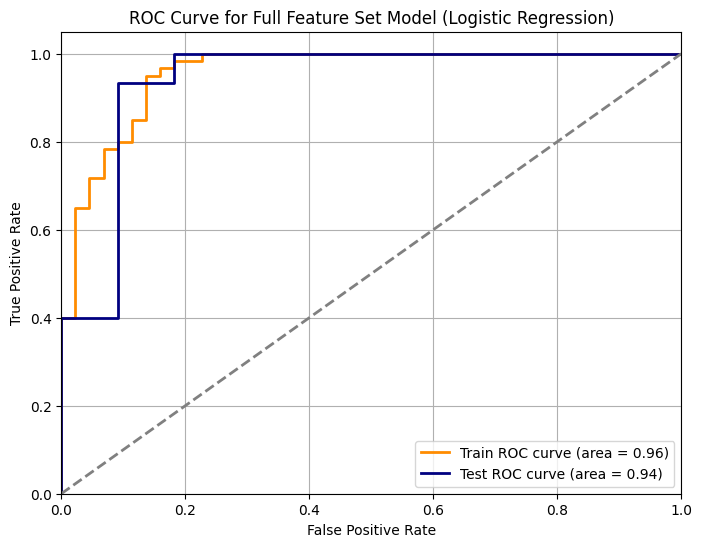

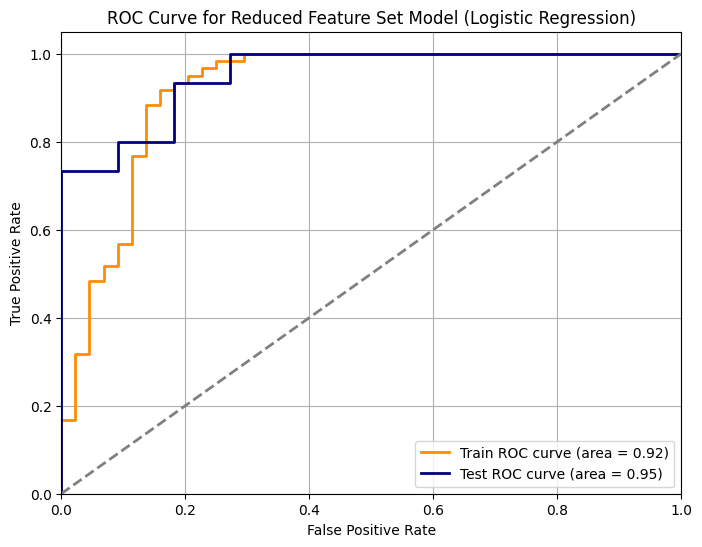

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- Plotting ROC Curves for Full Feature Set Model ---

# Get predictions for the training set (full features)
y_proba_train = best_model.predict_proba(X_train)[:, 1]

# Calculate ROC curve for training set
fpr_train, tpr_train, _ = roc_curve(y_train, y_proba_train)
roc_auc_train = auc(fpr_train, tpr_train)

# Calculate ROC curve for test set (full features)
fpr_test, tpr_test, _ = roc_curve(y_test, y_proba)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label=f'Train ROC curve (area = {roc_auc_train:.2f})')
plt.plot(fpr_test, tpr_test, color='navy', lw=2, label=f'Test ROC curve (area = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Full Feature Set Model (Logistic Regression)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# --- Plotting ROC Curves for Reduced Feature Set Model ---

# Get predictions for the training set (reduced features)
y_proba_train_reduced = best_model_reduced.predict_proba(X_train_reduced)[:, 1]

# Calculate ROC curve for training set (reduced features)
fpr_train_reduced, tpr_train_reduced, _ = roc_curve(y_train_reduced, y_proba_train_reduced)
roc_auc_train_reduced = auc(fpr_train_reduced, tpr_train_reduced)

# Calculate ROC curve for test set (reduced features)
fpr_test_reduced, tpr_test_reduced, _ = roc_curve(y_test_reduced, y_proba_reduced)
roc_auc_test_reduced = auc(fpr_test_reduced, tpr_test_reduced)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train_reduced, tpr_train_reduced, color='darkorange', lw=2, label=f'Train ROC curve (area = {roc_auc_train_reduced:.2f})')
plt.plot(fpr_test_reduced, tpr_test_reduced, color='navy', lw=2, label=f'Test ROC curve (area = {roc_auc_test_reduced:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Reduced Feature Set Model (Logistic Regression)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Test Set Evaluation for Random Forest (Reduced) and AdaBoost (Reduced)

In [ ]:
# Evaluate Random Forest (Reduced) on the test set
rf_reduced_model = models_reduced["Random Forest (Reduced)"]
y_pred_rf_reduced = rf_reduced_model.predict(X_test_reduced)
y_proba_rf_reduced = rf_reduced_model.predict_proba(X_test_reduced)[:, 1]

print("\n── Test Set Results (Random Forest Reduced) ──")
print(classification_report(y_test_reduced, y_pred_rf_reduced, target_names=["Unconfident", "Confident"]))
print(f"ROC-AUC: {roc_auc_score(y_test_reduced, y_proba_rf_reduced):.3f}")

# Evaluate AdaBoost (Reduced) on the test set
adaboost_reduced_model = models_reduced["AdaBoost (Reduced)"]
y_pred_ada_reduced = adaboost_reduced_model.predict(X_test_reduced)
y_proba_ada_reduced = adaboost_reduced_model.predict_proba(X_test_reduced)[:, 1]

print("\n── Test Set Results (AdaBoost Reduced) ──")
print(classification_report(y_test_reduced, y_pred_ada_reduced, target_names=["Unconfident", "Confident"]))
print(f"ROC-AUC: {roc_auc_score(y_test_reduced, y_proba_ada_reduced):.3f}")


── Test Set Results (Random Forest Reduced) ──
              precision    recall  f1-score   support

 Unconfident       1.00      0.82      0.90        11
   Confident       0.88      1.00      0.94        15

    accuracy                           0.92        26
   macro avg       0.94      0.91      0.92        26
weighted avg       0.93      0.92      0.92        26

ROC-AUC: 0.903

── Test Set Results (AdaBoost Reduced) ──
              precision    recall  f1-score   support

 Unconfident       1.00      0.82      0.90        11
   Confident       0.88      1.00      0.94        15

    accuracy                           0.92        26
   macro avg       0.94      0.91      0.92        26
weighted avg       0.93      0.92      0.92        26

ROC-AUC: 0.955


### Hyperparameter Tuning for XGBoost using GridSearchCV

I will now perform hyperparameter tuning for the XGBoost model using `GridSearchCV`. This involves defining a range of parameters to search through and evaluating different combinations using cross-validation to find the best performing set of hyperparameters.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the XGBoost pipeline (already created in models_reduced if we want to tune reduced)
# Let's use the full feature set XGBoost for this example.
xgb_pipeline = models["XGBoost"]

# Define the parameter grid to search
# Note: Parameters for pipeline steps are prefixed with the step name and two underscores
param_grid = {
    'model__n_estimators': [50, 100, 200], # Number of boosting rounds
    'model__max_depth': [3, 5, 7],         # Maximum tree depth
    'model__learning_rate': [0.01, 0.1, 0.2], # Step size shrinkage to prevent overfitting
    'model__subsample': [0.7, 0.9],        # Subsample ratio of the training instance
    'model__colsample_bytree': [0.7, 0.9]  # Subsample ratio of columns when constructing each tree
}

# Instantiate GridSearchCV with GroupKFold for cross-validation
# We'll use the full feature set and groups for tuning.
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=gkf, # Use the previously defined GroupKFold object
    scoring='roc_auc',
    n_jobs=-1, # Use all available cores
    verbose=1
)

print("Starting GridSearchCV for XGBoost...")
# Fit the grid search to the training data
grid_search.fit(X_train, y_train, groups=groups_train)

print("GridSearchCV completed.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation ROC-AUC score: {grid_search.best_score_:.3f}")

# Get the best model from the grid search
best_xgb_model = grid_search.best_estimator_

# Evaluate the best XGBoost model on the test set
y_pred_xgb = best_xgb_model.predict(X_test)
y_proba_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

print("\n── Test Set Results for Tuned XGBoost ──")
print(classification_report(y_test, y_pred_xgb, target_names=["Unconfident", "Confident"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.3f}")

Starting GridSearchCV for XGBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
GridSearchCV completed.
Best parameters found: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 50, 'model__subsample': 0.7}
Best cross-validation ROC-AUC score: 0.891

── Test Set Results for Tuned XGBoost ──
              precision    recall  f1-score   support

 Unconfident       1.00      0.82      0.90        11
   Confident       0.88      1.00      0.94        15

    accuracy                           0.92        26
   macro avg       0.94      0.91      0.92        26
weighted avg       0.93      0.92      0.92        26

ROC-AUC: 0.903


### Training and Saving an Ensemble Model

In [ ]:
from sklearn.ensemble import VotingClassifier
import joblib # For saving and loading models

# Define the individual models for the ensemble.
# We'll use the models trained on the reduced feature set for consistency
# across the ensemble, as they showed strong performance.
# Note: best_xgb_model was tuned on the full feature set. For this ensemble
# using reduced features, we'll use the untuned XGBoost from models_reduced.

estimators = [
    ('lr', models_reduced["Logistic Regression (Reduced)"]),
    ('rf', models_reduced["Random Forest (Reduced)"]),
    ('xgb', models_reduced["XGBoost (Reduced)"]),
    ('ada', models_reduced["AdaBoost (Reduced)"])
]

# Create the VotingClassifier (soft voting for probabilities)
# Weights can be adjusted based on individual model performance or tuning.
# For now, equal weights.
ensemble_model = VotingClassifier(estimators=estimators, voting='soft', weights=[1, 1, 1, 1], n_jobs=-1)

print("Fitting ensemble model...")
# Fit the ensemble model on the reduced training data
ensemble_model.fit(X_train_reduced, y_train_reduced)
print("Ensemble model fitted.")

# Evaluate the ensemble model on the reduced test set
y_pred_ensemble = ensemble_model.predict(X_test_reduced)
y_proba_ensemble = ensemble_model.predict_proba(X_test_reduced)[:, 1]

print("\n── Test Set Results (Ensemble Model - Reduced Features) ──")
print(classification_report(y_test_reduced, y_pred_ensemble, target_names=["Unconfident", "Confident"]))
print(f"ROC-AUC: {roc_auc_score(y_test_reduced, y_proba_ensemble):.3f}")

# --- Save the trained ensemble model and the feature list ---

# Define paths for saving
model_save_path = '/content/drive/MyDrive/Confidence_Analysis_vms/ensemble_confidence_model.joblib'
features_save_path = '/content/drive/MyDrive/Confidence_Analysis_vms/features_list.joblib'

# Save the ensemble model
joblib.dump(ensemble_model, model_save_path)
print(f"Ensemble model saved to: {model_save_path}")

# Save the feature list
joblib.dump(FEATURES_REDUCED, features_save_path)
print(f"Feature list saved to: {features_save_path}")

Fitting ensemble model...
Ensemble model fitted.

── Test Set Results (Ensemble Model - Reduced Features) ──
              precision    recall  f1-score   support

 Unconfident       0.90      0.82      0.86        11
   Confident       0.88      0.93      0.90        15

    accuracy                           0.88        26
   macro avg       0.89      0.88      0.88        26
weighted avg       0.89      0.88      0.88        26

ROC-AUC: 0.927
Ensemble model saved to: /content/drive/MyDrive/Confidence_Analysis_vms/ensemble_confidence_model.joblib
Feature list saved to: /content/drive/MyDrive/Confidence_Analysis_vms/features_list.joblib


### Using the Ensemble Model in VS Code

To use this trained ensemble model in your VS Code project, you'll need to:

1.  **Transfer the saved files:** Download `ensemble_confidence_model.joblib` and `features_list.joblib` from your Google Drive (or copy them if your VS Code project can access the same Google Drive path).

2.  **Load the model and features:** In your Python script within VS Code, load these files using `joblib`:

    ```python
    import joblib
    import pandas as pd
    # Assuming you have the predict_confidence_for_audio_automated function or similar feature extraction logic
    from your_feature_extraction_module import predict_confidence_for_audio_automated, get_audio_features_from_transcription_and_wav

    # Load the trained ensemble model
    ensemble_model = joblib.load('path/to/your/ensemble_confidence_model.joblib')

    # Load the list of feature names
    feature_names = joblib.load('path/to/your/features_list.joblib')
    ```

3.  **Prepare new audio for prediction:** For any new audio file, you'll need to extract the features in the exact same way as was done during training. This involves:
    *   Converting M4A to WAV if necessary.
    *   Transcribing with Whisper.
    *   Extracting `filler_words`, `speech_rate`, `total_repeated_words`, `total_pauses`, `average_pause_duration`, and `pause_per_word` using logic similar to `get_audio_features_from_transcription_and_wav`.

    ```python
    # Example of feature extraction for a new audio file
    new_audio_file_path = 'path/to/your/new_audio.m4a' # or .wav
    # You would use the automated feature extraction logic here, similar to what we built
    # For demonstration, let's assume `predict_confidence_for_audio_automated` returns the features dict
    # You would need to adapt the feature extraction pipeline to run independently in your VS Code environment.
    # For instance, you'd integrate whisper, pydub, etc., directly in your VS Code project.

    # Simplified example of extracted features (replace with actual extraction logic):
    extracted_features_dict = {
        "filler_words": 2,
        "speech_rate": 140.5,
        "total_repeated_words": 1,
        "total_pauses": 5,
        "average_pause_duration": 0.6,
        "pause_per_word": 0.03
    }

    # Convert the extracted features dictionary to a DataFrame, ensuring correct column order
    input_df = pd.DataFrame([extracted_features_dict], columns=feature_names)
    ```

4.  **Make Predictions:** Use the loaded ensemble model to predict the confidence probability and score.

    ```python
    # Predict probability (P(Confident=1))
    proba = ensemble_model.predict_proba(input_df)[:, 1][0]

    # Predict the label
    predicted_label = "Confident" if proba >= 0.5 else "Unconfident"

    # Convert probability to 1-10 confidence score
    confidence_score_1_to_10 = 1 + 9 * proba

    print(f"Predicted Label: {predicted_label}")
    print(f"Confidence Probability: {proba:.2f}")
    print(f"Confidence Score (1-10): {confidence_score_1_to_10:.1f}")
    ```

Remember to install all necessary Python libraries (`scikit-learn`, `pandas`, `pydub`, `whisper`, `joblib`, `xgboost` etc.) in your VS Code environment (`pip install ...`).

### Standalone Python Script for VS Code Integration

In [ ]:
#!/usr/bin/env python

import os
import pandas as pd
import numpy as np
import joblib
import whisper
import tempfile
import shutil
from pydub import AudioSegment
from pydub.silence import detect_silence
from sklearn.pipeline import Pipeline # Required for type hinting and joblib loading
from sklearn.ensemble import VotingClassifier # Required for joblib loading
# Ensure all scikit-learn, xgboost, and other classes used in pipelines are imported if they are not part of the standard Python library
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import xgboost as xgb

# --- Configuration --- #
# IMPORTANT: Update these paths to where you saved your model and features list
MODEL_PATH = '/content/drive/MyDrive/Confidence_Analysis_vms/ensemble_confidence_model.joblib'
FEATURES_LIST_PATH = '/content/drive/MyDrive/Confidence_Analysis_vms/features_list.joblib'

# --- Helper Functions (copied from Colab notebook) --- #

def get_audio_features_from_transcription_and_wav(
    wav_file_path: str,
    transcription: str,
    audio_duration_seconds: float
) -> dict:
    """
    Extracts relevant audio features from a WAV file using transcription for
    filler words, speech rate, and repeated words, and pydub for pauses.

    Args:
        wav_file_path (str): The path to the (temporary) WAV audio file.
        transcription (str): The text transcription of the audio.
        audio_duration_seconds (float): The total duration of the audio in seconds.

    Returns:
        dict: A dictionary of extracted features, ready for prediction.
    """
    if not os.path.exists(wav_file_path):
        raise FileNotFoundError(f"Audio file not found: {wav_file_path}")

    audio = AudioSegment.from_wav(wav_file_path)

    # --- Feature extraction from transcription ---
    words = transcription.lower().split()
    word_count = len(words)

    # Simple Filler words detection
    filler_words_list = ['um', 'uh', 'like', 'you know', 'so', 'basically', 'actually', 'literally']
    filler_words_count = sum(1 for word in words if word in filler_words_list)

    # Speech rate calculation (words per minute)
    speech_rate = (word_count / audio_duration_seconds) * 60 if audio_duration_seconds > 0 else 0.0

    # Repeated words detection (simple consecutive repetition)
    total_repeated_words = 0
    for i in range(len(words) - 1):
        if words[i] == words[i+1]:
            total_repeated_words += 1

    # --- Pause detection using pydub ---
    # Adjust silence_thresh to be relative to the audio's average loudness
    silence_threshold_db = audio.dBFS - 10
    silences = detect_silence(audio, min_silence_len=500, silence_thresh=silence_threshold_db)

    total_pauses = len(silences)
    average_pause_duration = 0.0
    if total_pauses > 0:
        total_pause_duration_ms = sum([s[1] - s[0] for s in silences])
        average_pause_duration = total_pause_duration_ms / total_pauses / 1000.0 # convert to seconds

    # Calculate pause_per_word
    pause_per_word = total_pauses / speech_rate if speech_rate > 0 else 0.0

    features = {
        "filler_words": filler_words_count,
        "speech_rate": speech_rate,
        "total_repeated_words": total_repeated_words,
        "total_pauses": total_pauses,
        "average_pause_duration": average_pause_duration,
        "pause_per_word": pause_per_word
    }
    return features

def predict_confidence_score(
    features_dict: dict,
    model: Pipeline,
    feature_names: list
) -> dict:
    """
    Predicts the confidence score for a new audio recording given its extracted features.

    Args:
        features_dict (dict): A dictionary where keys are feature names and values are their corresponding numeric values.
        model (Pipeline): The trained scikit-learn pipeline (or VotingClassifier).
        feature_names (list): A list of feature names in the correct order as used during training.

    Returns:
        dict: A dictionary containing the predicted label, confidence probability, and a 1-10 confidence score.
    """
    # Create a DataFrame from the input features_dict
    # It's important to match the column order used during training
    input_df = pd.DataFrame([features_dict], columns=feature_names)

    # Predict probability (P(Confident=1))
    proba = model.predict_proba(input_df)[:, 1][0]

    # Predict the label
    label = "Confident" if proba >= 0.5 else "Unconfident"

    # Convert probability to 1-10 confidence score
    confidence_score_1_to_10 = 1 + 9 * proba

    return {
        "predicted_label": label,
        "confidence_probability": proba,
        "confidence_score_1_to_10": confidence_score_1_to_10
    }

# --- Main Prediction Function for VS Code --- #

# Load the Whisper model once globally to avoid re-loading for each prediction call
# This can be changed if memory is a constraint and only one prediction is made at a time.
print("Loading Whisper model (this may take a moment on first run)...")
WHISPER_MODEL = whisper.load_model("small") # Consider 'base', 'medium' for better accuracy if needed
print("Whisper model loaded.")

def predict_confidence_for_audio_vscode(audio_file_path: str) -> dict:
    """
    Predicts confidence scores for a given audio file (m4a, mp3, or wav) using
    Whisper for transcription and the loaded ensemble model.

    Args:
        audio_file_path (str): The path to the audio file (m4a, mp3, or wav).

    Returns:
        dict: A dictionary containing the prediction results.
    """
    print(f"Processing audio file: {audio_file_path}")

    if not os.path.exists(audio_file_path):
        print(f"Error: Audio file not found at {audio_file_path}")
        return {}

    temp_dir = tempfile.mkdtemp()
    temp_wav_path = os.path.join(temp_dir, "temp_audio.wav")

    try:
        # Step 1: Convert to WAV if necessary (pydub handles various formats)
        audio = AudioSegment.from_file(audio_file_path)
        audio.export(temp_wav_path, format="wav")
        audio_duration_seconds = len(audio) / 1000.0

        # Step 2: Transcribe with Whisper
        print("Transcribing audio with Whisper...")
        result = WHISPER_MODEL.transcribe(temp_wav_path)
        transcription = result["text"]
        print(f"Transcription: \"{transcription}\"")

        # Step 3: Extract features
        extracted_features = get_audio_features_from_transcription_and_wav(
            wav_file_path=temp_wav_path,
            transcription=transcription,
            audio_duration_seconds=audio_duration_seconds
        )

        print("\nAutomatically Extracted Features:")
        for k, v in extracted_features.items():
            print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")

        # Step 4: Load the model and feature names
        # These are loaded here to make the function self-contained
        # but in a real application, you might load them once at startup.
        try:
            ensemble_model = joblib.load(MODEL_PATH)
            feature_names = joblib.load(FEATURES_LIST_PATH)
        except FileNotFoundError:
            print(f"Error: Model or feature list not found. Ensure '{MODEL_PATH}' and '{FEATURES_LIST_PATH}' exist.")
            return {}
        except Exception as e:
            print(f"Error loading model or feature list: {e}")
            return {}

        # Step 5: Predict confidence
        prediction = predict_confidence_score(
            features_dict=extracted_features,
            model=ensemble_model,
            feature_names=feature_names
        )

        print("\n--- Prediction Results ---")
        print(f"  Predicted Label: {prediction['predicted_label']}")
        print(f"  Confidence Probability (P(Confident)): {prediction['confidence_probability']:.2f}")
        print(f"  Confidence Score (1-10): {prediction['confidence_score_1_to_10']:.1f}")

        return prediction

    except Exception as e:
        print(f"An unexpected error occurred during prediction: {e}")
        return {}
    finally:
        # Clean up the temporary directory
        if os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)
            print(f"Cleaned up temporary directory: {temp_dir}")

# --- Example Usage (only runs when the script is executed directly) --- #
if __name__ == "__main__":
    # IMPORTANT: Change this to the actual path of an audio file on your system.
    AUDIO_FILE_TO_PREDICT = '/content/drive/MyDrive/Confidence_Analysis_vms/Test Data/Confident.m4a'

    if os.path.exists(AUDIO_FILE_TO_PREDICT):
        results = predict_confidence_for_audio_vscode(AUDIO_FILE_TO_PREDICT)
        if results:
            print("\nFinal Prediction Results:")
            print(f"  Predicted Label: {results['predicted_label']}")
            print(f"  Confidence Score (1-10): {results['confidence_score_1_to_10']:.1f}")
    else:
        print(f"Error: The example audio file '{AUDIO_FILE_TO_PREDICT}' was not found.")
        print("Please update AUDIO_FILE_TO_PREDICT to a valid path on your system.")
        print("Also, ensure MODEL_PATH and FEATURES_LIST_PATH at the top of this script are correct.")
